# Phase 10: Risk Engine Validation Notebook
This notebook demonstrates and validates the implementation of:
1. **Vectorized Greeks via PyTorch Reverse-Mode AD (VJPs)** and support for second-order Greek supervision in FNO.
2. **Warp-aligned GPU Monte Carlo Path Simulation** using block-tiled random normal generation to maximize GPU coalesced memory reads.
3. **Synchronization-free VaR & Expected Shortfall (ES)** using GPU radix sorting (`torch.sort`) and static slicing.
4. **Model Governance & Compliance (SR 26-2)** online drift tracking (Population Stability Index - PSI) and out-of-distribution (OOD) parameter clamping.


Device: cuda


Greeks calculated in 82.02 ms


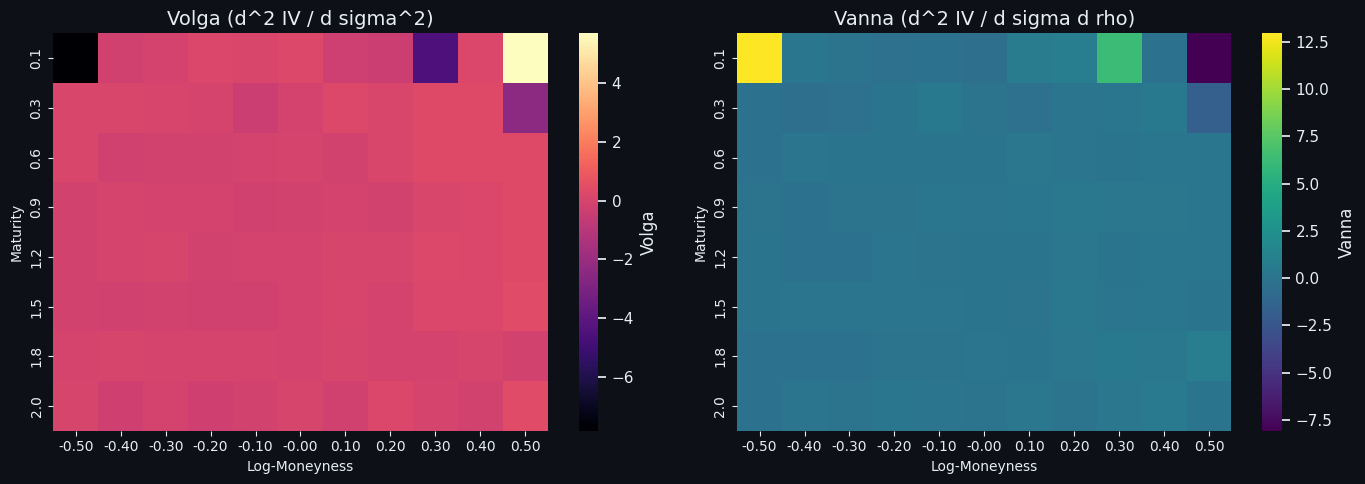

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Ensure package is on path
project_root = os.path.dirname(os.path.abspath(""))
sys.path.insert(0, os.path.join(project_root, "src"))

from deepvol.surrogates.fno_model import MirrorPaddedFNO2d
from deepvol.surrogates.fno_greeks import compute_greeks

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load model
model = MirrorPaddedFNO2d()
weights_path = os.path.join(project_root, "artifacts/weights/fno_v2_final_prod.pth")
if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

# Parameters
params = torch.tensor([2.5, 0.08, 0.5, -0.5, 0.08, 0.08], dtype=torch.float32, device=device, requires_grad=True)
T_grid = torch.tensor([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0], dtype=torch.float32, device=device)
K_grid = torch.linspace(-0.5, 0.5, 11, dtype=torch.float32, device=device)

# Warmup
_, _ = compute_greeks(model, params, T_grid, K_grid)

# Measure speed
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
volga_t, vanna_t = compute_greeks(model, params, T_grid, K_grid)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t1 = time.perf_counter()
print(f"Greeks calculated in {(t1 - t0)*1000.0:.2f} ms")

# Detach and convert for plotting
volga = volga_t.detach().cpu().numpy()
vanna = vanna_t.detach().cpu().numpy()

# Plot Volga and Vanna
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0D1117")
sns.set(style="dark")
K_labels = [f"{k:.2f}" for k in K_grid.cpu().numpy()]
T_labels = [f"{t:.1f}" for t in T_grid.cpu().numpy()]

ax1 = axes[0]
sns.heatmap(volga, xticklabels=K_labels, yticklabels=T_labels, cmap="magma", ax=ax1, cbar_kws={'label': 'Volga'})
ax1.set_title("Volga (d^2 IV / d sigma^2)", color="#E6EDF3", fontsize=14)
ax1.set_xlabel("Log-Moneyness", color="#E6EDF3")
ax1.set_ylabel("Maturity", color="#E6EDF3")
ax1.tick_params(colors="#E6EDF3")

ax2 = axes[1]
sns.heatmap(vanna, xticklabels=K_labels, yticklabels=T_labels, cmap="viridis", ax=ax2, cbar_kws={'label': 'Vanna'})
ax2.set_title("Vanna (d^2 IV / d sigma d rho)", color="#E6EDF3", fontsize=14)
ax2.set_xlabel("Log-Moneyness", color="#E6EDF3")
ax2.set_ylabel("Maturity", color="#E6EDF3")
ax2.tick_params(colors="#E6EDF3")

for cbar_ax in fig.axes[2:]:
    cbar_ax.yaxis.label.set_color('#E6EDF3')
    cbar_ax.tick_params(colors='#E6EDF3')

plt.tight_layout()
plt.show()

## 2. GPU Monte Carlo & Sync-Free VaR/ES Engine
The GPU Monte Carlo engine implements two critical performance design patterns:
1. **Warp-aligned block-tiled random numbers**: Tensors of shape `(2 * N_steps, PATHS_padded)` are generated and reshaped to `(num_blocks, 2 * N_steps, block_size)`. This ensures that thread access within each GPU warp is strictly contiguous and aligned, maximizing memory bandwidth.
2. **Synchronization-free VaR & ES calculation**: Option pricing and scenario loss aggregation are run on the GPU. Radix sort (`torch.sort`) and tail slicing are performed directly on GPU VRAM, eliminating expensive host-to-device synchronization roundtrips.


skipping cudagraphs due to skipping cudagraphs due to cpu device (arg1_1). Found from : 
   File "/home/execorn/programming/derivatives-w2/src/deepvol/risk/portfolio_mc.py", line 41, in heston_sde_step
    Z1 = rho * Z2 + math.sqrt(1.0 - rho**2) * Z3



skipping cudagraphs due to skipping cudagraphs due to cpu device (arg2_1). Found from : 
   File "/home/execorn/programming/derivatives-w2/src/deepvol/risk/portfolio_mc.py", line 44, in torch_dynamo_resume_in_heston_sde_step_at_41
    V_next = V_t + kappa * (theta_param - V_prev_pos) * delta_t + sigma * torch.sqrt(V_prev_pos) * math.sqrt(delta_t) * Z2



VaR and ES computed in 345.24 ms
95% Value-at-Risk: 1773.3843
95% Expected Shortfall: 2232.5935


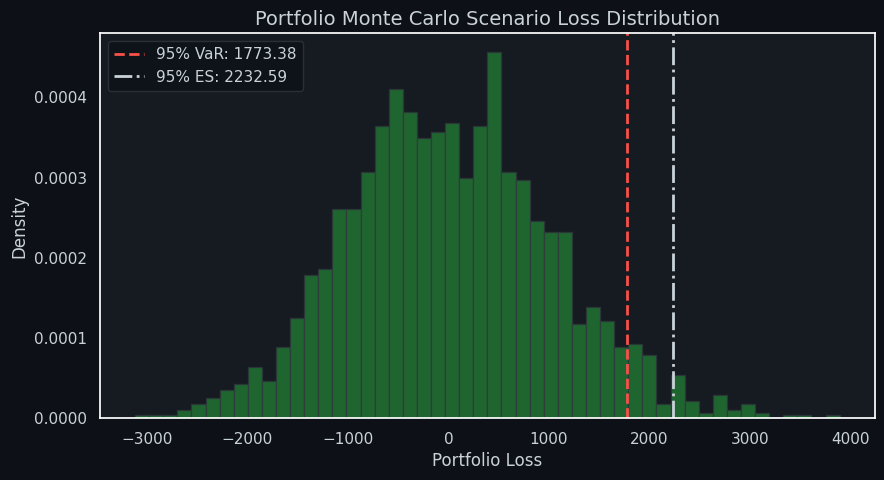

In [2]:
from deepvol.surrogates.normalizers import ParameterNormalizer, IVSurfaceNormalizer
from deepvol.risk.portfolio_mc import MonteCarloVaREngine

# Load normalizers
pn = ParameterNormalizer.load(os.path.join(project_root, "artifacts/models/param_normalizer_v2.npz"))
yn = IVSurfaceNormalizer.load(os.path.join(project_root, "artifacts/models/iv_normalizer_v2.npz"))

var_engine = MonteCarloVaREngine(model, pn, yn, device)

S0 = 100.0
theta = np.array([2.5, 0.08, 0.5, -0.5, 0.08, 0.08])
r = 0.05

# Setup a portfolio of 100 random call/put positions
np.random.seed(42)
positions = []
for _ in range(100):
    positions.append({
        "K": float(np.random.uniform(95.0, 105.0)),
        "T": float(np.random.uniform(0.1, 1.8)),
        "type": "call" if np.random.rand() > 0.5 else "put",
        "quantity": float(np.random.uniform(-2.0, 2.0)),
        "notional": 100.0
    })

# Warmup to compile functions
_ = var_engine.compute_portfolio_var_es(
    positions=positions, S0=S0, theta=theta, r=r,
    N_paths=2000, N_steps=5, alpha=0.95, block_size=4096, seed=42
)

# Benchmark latency
if torch.cuda.is_available():
    torch.cuda.synchronize()
t_start = time.perf_counter()

res = var_engine.compute_portfolio_var_es(
    positions=positions, S0=S0, theta=theta, r=r,
    N_paths=2000, N_steps=5, alpha=0.95, block_size=4096, seed=42
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
t_end = time.perf_counter()
print(f"VaR and ES computed in {(t_end - t_start)*1000.0:.2f} ms")
print(f"95% Value-at-Risk: {res['var']:.4f}")
print(f"95% Expected Shortfall: {res['es']:.4f}")

# Plot loss distribution
plt.figure(figsize=(10, 5), facecolor="#0D1117")
ax = plt.axes()
ax.set_facecolor("#161B22")
plt.hist(res["losses"], bins=50, color="#238636", edgecolor="#30363D", density=True, alpha=0.7)
plt.axvline(res["var"], color="#F85149", linestyle="--", linewidth=2, label=f"95% VaR: {res['var']:.2f}")
plt.axvline(res["es"], color="#C9D1D9", linestyle="-.", linewidth=2, label=f"95% ES: {res['es']:.2f}")

plt.title("Portfolio Monte Carlo Scenario Loss Distribution", color="#C9D1D9", fontsize=14)
plt.xlabel("Portfolio Loss", color="#C9D1D9")
plt.ylabel("Density", color="#C9D1D9")
ax.tick_params(colors="#C9D1D9")
plt.legend(facecolor="#0D1117", edgecolor="#30363D", labelcolor="#C9D1D9")
plt.show()


## 3. Model Governance & Compliance (SR 26-2)
Under the SR 26-2 model risk guidelines:
- **OOD Detection & Clamping**: Input Heston parameters are checked against the FNO training bounds. Out-of-bounds parameters are clamped to prevent mathematical singularities, and a structured warning log in JSON format is written.
- **Online Parameter Drift Tracking**: Calibration parameters are recorded in a rolling window. The Population Stability Index (PSI) is calculated dynamically for each parameter against the expected distribution. Drift metrics are logged automatically.


In [3]:
import logging
from deepvol.mrm.compliance import check_compliance, _global_monitor

# Configure root logger to output to stdout so we can see the compliance logs here
logging.basicConfig(level=logging.WARNING, force=True)

# 1. Trigger OOD parameter detection (kappa=12.0 is OOD, H=0.35 is OOD)
print("--- Demonstrating OOD Detection & Clamping ---")
theta_ood = np.array([12.0, 0.08, 0.5, -0.5, 0.08, 0.35])
theta_clamped = check_compliance(theta_ood)
print("Original parameters: ", theta_ood)
print("Clamped parameters:  ", theta_clamped)

# 2. Trigger Parameter Drift Warning via PSI
print("\n--- Demonstrating Parameter Drift Tracking ---")
# Clear global monitor history
_global_monitor.history.clear()

# Add 50 in-bounds parameters (Expected distribution)
for _ in range(50):
    _global_monitor.add_parameters(np.array([2.5, 0.08, 0.5, -0.5, 0.08, 0.08]))

# Add 50 drifted parameters (Actual distribution)
print("Injecting drifted parameters to trigger PSI warnings:")
for _ in range(50):
    _global_monitor.add_parameters(np.array([4.5, 0.20, 1.3, -0.1, 0.20, 0.13]))

# Compute PSI and show drift warning
_ = _global_monitor.compute_psi()

--- Demonstrating OOD Detection & Clamping ---
Original parameters:  [12.    0.08  0.5  -0.5   0.08  0.35]
Clamped parameters:   [ 5.    0.08  0.5  -0.5   0.08  0.15]

--- Demonstrating Parameter Drift Tracking ---
Injecting drifted parameters to trigger PSI warnings:
